In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [16]:
## -- load JWST spectrum
l = np.load('./data/spec_fits_R100_case2.npz')
jwst_waves = l['waves']
jwst_wavehws = l['wavehws']
jwst_fits = l['fits']
jwst_errs = l['errs']
del l

## -- calculate JWST transit depths
jwst_depths = 1.e6*(jwst_fits[:,1]**2)
jwst_deptherrs = 1.e6*(2.*jwst_fits[:,1]*jwst_errs[:,1])


## -- load JWST retrieval


## -- load HST spectrum
hst_dat = np.loadtxt('./data/Barat_et_al_v1298_tauc_free_recte_spectra_order2.txt', skiprows=1, unpack=True)
hst_waves = hst_dat[0]
hst_depths = hst_dat[2]
hst_deptherrs = hst_dat[3]

## -- load HST model
hst_m = np.loadtxt('./data/Barat_et_al_v1298_tauc_atmo_model.txt', unpack=True)
hst_modelwaves = hst_m[0]
hst_model = hst_m[1]

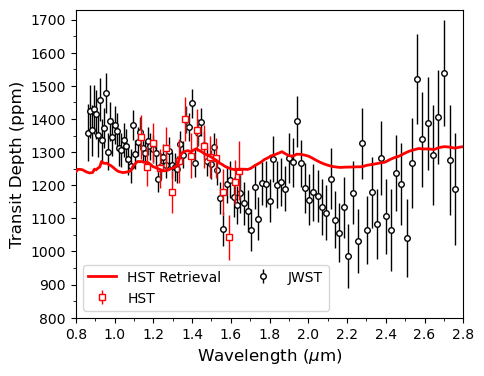

In [31]:
fig, ax = plt.subplots(figsize=(5,4))
ax.errorbar(hst_waves, hst_depths, hst_deptherrs, ls='None', lw=1, zorder=8, marker='s', ms=5, c='red', mec='red', mfc='white', alpha=1, label='HST')
ax.errorbar(hst_waves, hst_depths, hst_deptherrs, ls='None', lw=1, zorder=7, marker='s', ms=5, c='white', mec='white', mfc='white', alpha=1)
ax.plot(hst_modelwaves, hst_model, lw=2, c='red', zorder=10, label='HST Retrieval')

ax.errorbar(jwst_waves, jwst_depths, jwst_deptherrs, ls='None', lw=1, zorder=1, marker='o', ms=4, c='black', mec='black', mfc='white', alpha=1, label='JWST')
ax.legend(loc='lower left', ncol=2)
ax.set_ylabel(r'Transit Depth (ppm)', fontsize=12)
ax.set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax.set_xlim(0.8,2.8)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_ylim(800,1730)
ax.yaxis.set_major_locator(MultipleLocator(100))
ax.yaxis.set_minor_locator(MultipleLocator(50))

plt.savefig('./figures/Figure6.png', dpi=600, bbox_inches='tight')
plt.show()